# EDA for Malaysia Residential Property Data 

In [46]:
import pandas as pd # for data manipulation and analysis
import numpy as np
import missingno as msno # uncovering missing data patterns in datasets
import matplotlib.pyplot as plt # for plotting graph
import seaborn as sns

In [47]:
df = pd.read_csv('Malaysia Residential Property Data.csv', sep='\t', encoding='utf-8')

In [48]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [49]:

df.dtypes

Property Type                       object
District                            object
Mukim                               object
Scheme Name/Area                    object
Road Name                           object
Month, Year of Transaction Date     object
Tenure                              object
Land/Parcel Area                    object
Unit                                object
Main Floor Area                     object
Unit                                object
Unit Level                          object
Transaction Price                   object
Unnamed: 13                        float64
dtype: object

In [50]:
df.shape

(410959, 14)

<Axes: >

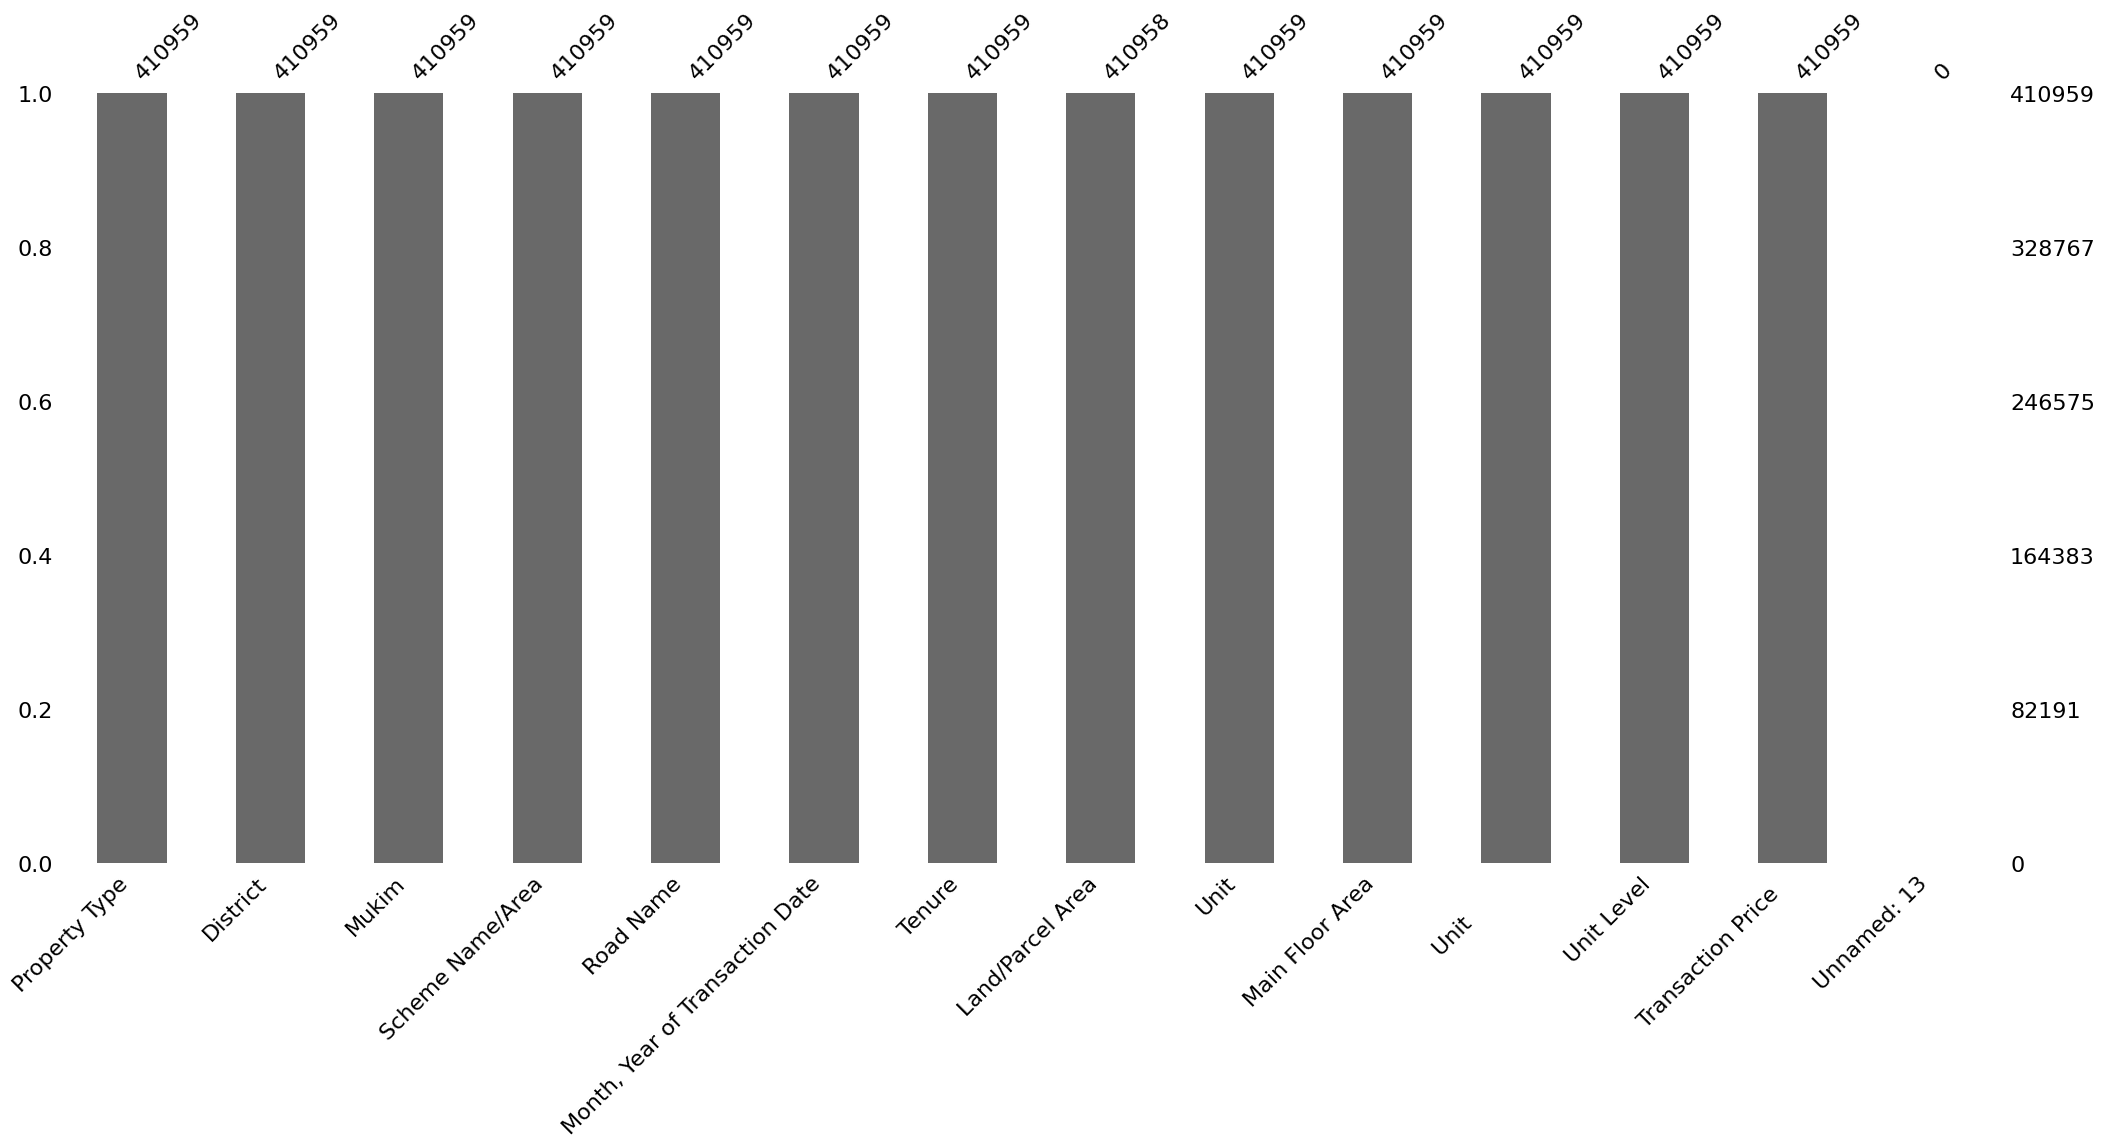

In [51]:
msno.bar(df) 

In [52]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [53]:

df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(447)

In [54]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  1
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  410959


**Data wrangling**

In [55]:

df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [56]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [57]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

['374.00' '234.00' '268.00' ... '132.28' '70.29' '359.63']
Series([], Name: Land/Parcel Area, dtype: object)
['106' '67' '118' '116' '217' '143' '82' '133' '117' '93' '112' '130'
 '160' '108' '126' '115' '153' '105' '109' '123' '136' '142' '167' '211'
 '157' '121' '165' '144' '124' '139' '102' '138' '127' '99' '96' '101'
 '110' '90' '129' '114' '132' '107' '92' '95' '81' '85' '88' '86' '131'
 '84' '89' '103' '98' '120' '111' '137' '134' '188' '182' '100' '147'
 '113' '135' '122' '178' '125' '119' '128' '166' '77' '74' '104' '73' '69'
 '59' '76' '91' '71' '94' '72' '79' '87' '141' '75' '280' '83' '159' '97'
 '174' '55' '68' '78' '154' '206' '65' '150' '158' '163' '151' '168' '155'
 '198' '162' '200' '148' '164' '189' '80' '173' '146' '152' '62' '70' '66'
 '172' '53' '50' '204' '145' '48' '179' '140' '171' '149' '219' '61' '202'
 '186' '185' '183' '180' '60' '190' '58' '205' '222' '184' '191' '213'
 '181' '223' '156' '177' '199' '195' '405' '399' '268' '332' '57' '207'
 '176' '339' '54' 

In [58]:
# Convert 'Month, Year of Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Month, Year of Transaction Date'], format='%B %Y')

In [59]:
df = df.drop(columns=['Unnamed: 13', 'Unit Level'], errors='ignore')
print(df.columns.tolist())

['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Transaction Price', 'Transaction Date']


**Analayze data after data wrangling**

In [60]:

df.dtypes

Property Type                              object
District                                   object
Mukim                                      object
Scheme Name/Area                           object
Road Name                                  object
Month, Year of Transaction Date            object
Tenure                                     object
Land/Parcel Area                          float64
Unit                                       object
Main Floor Area                           float64
Unit                                       object
Transaction Price                         float64
Transaction Date                   datetime64[ns]
dtype: object

<Axes: >

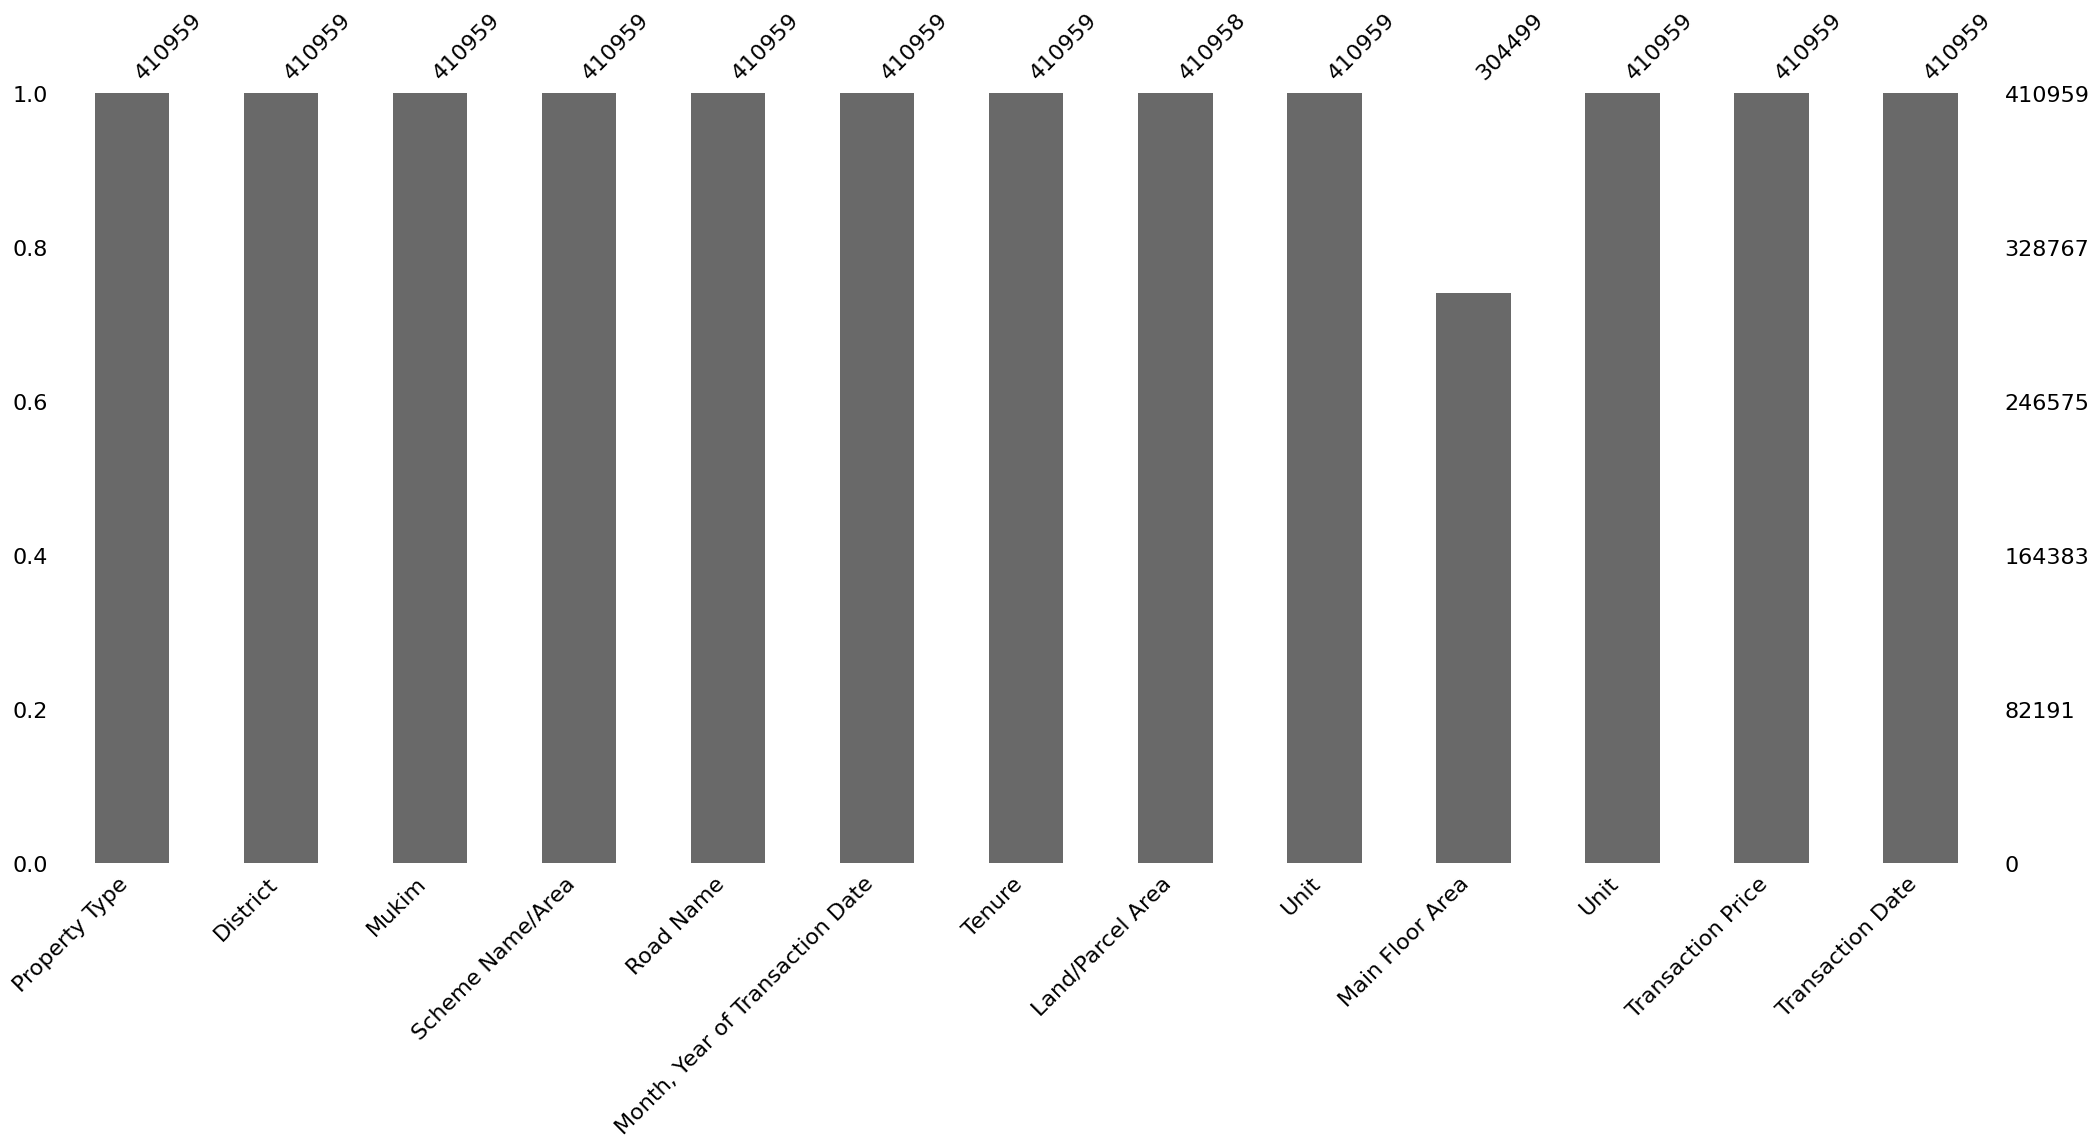

In [61]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

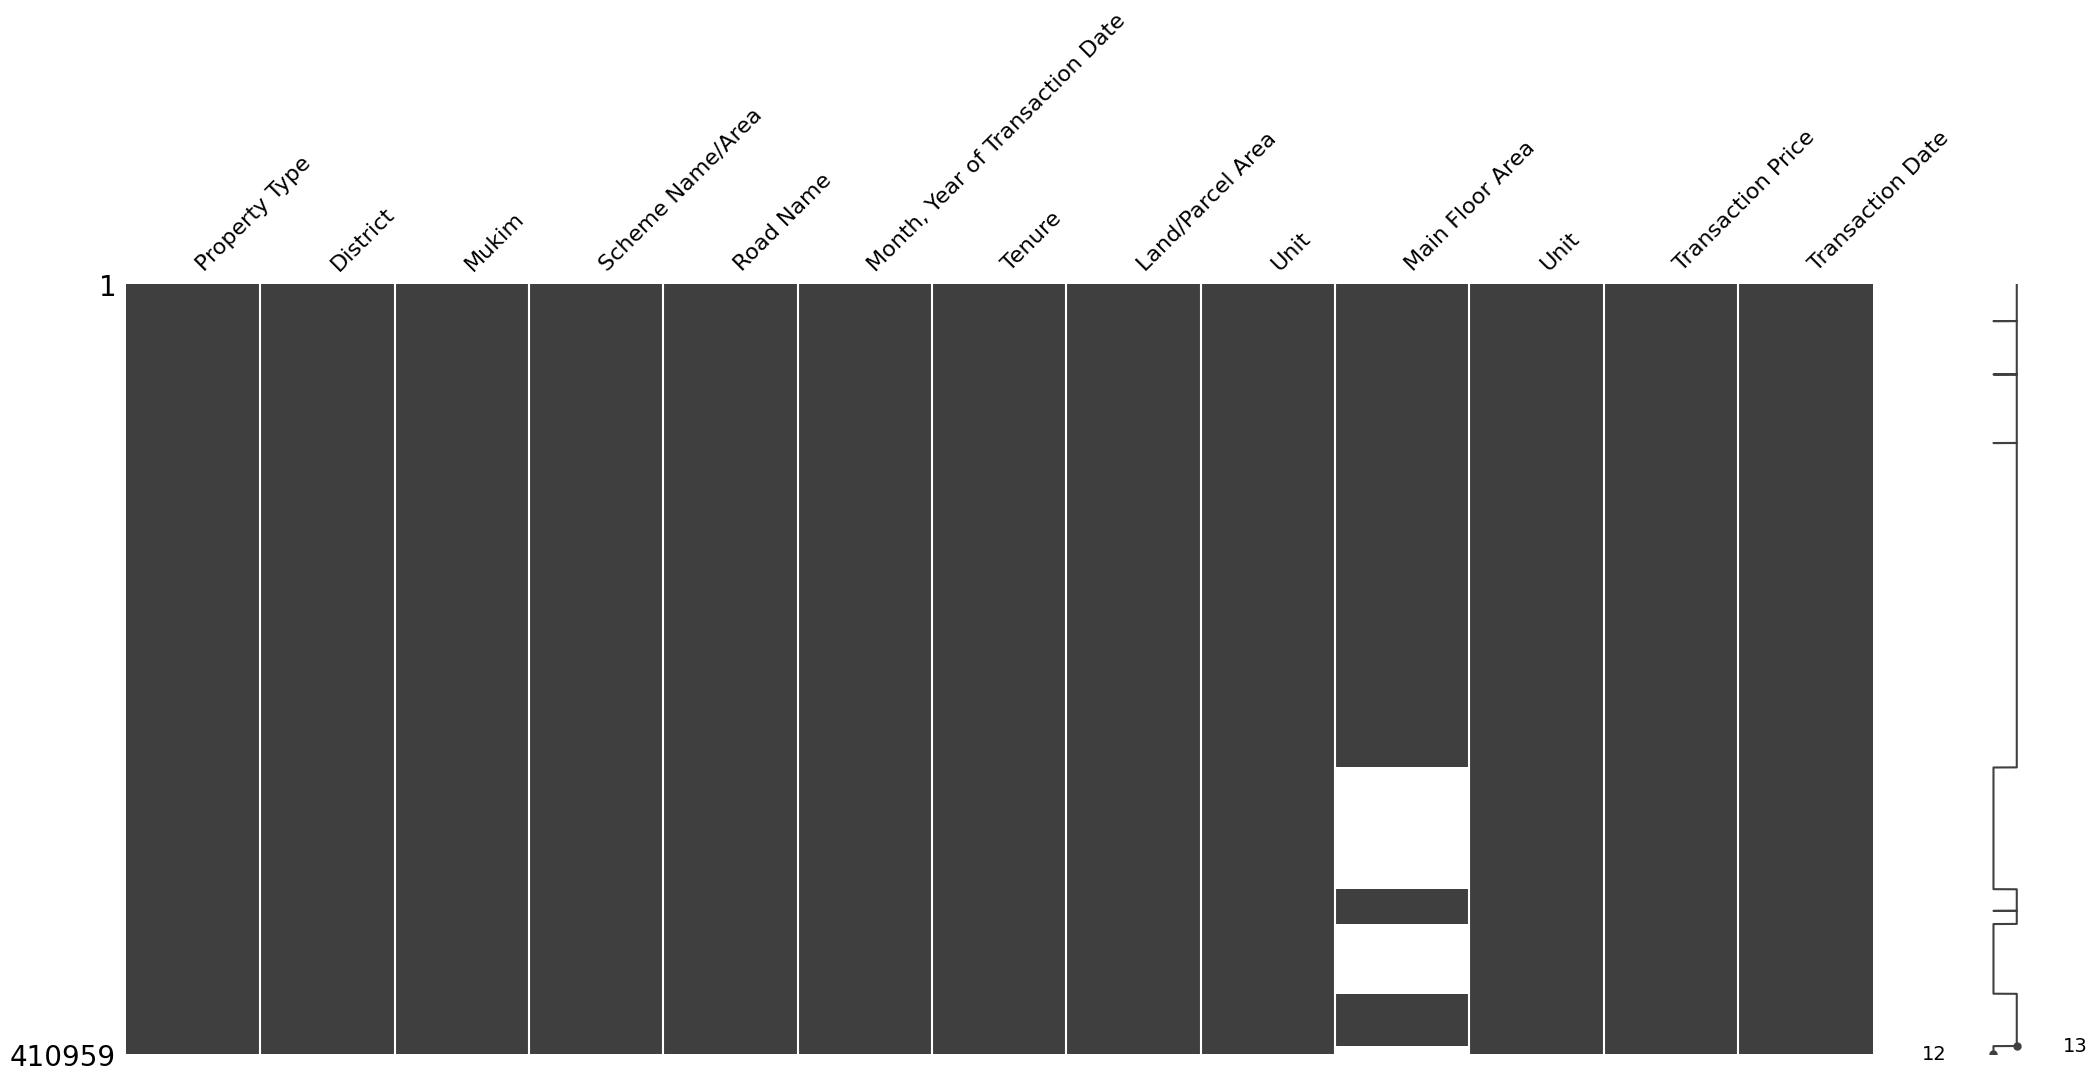

In [62]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

**Handle missing values**

In [63]:
# Handle missing values in 'Main Floor Area' by filling with the median
df['Main Floor Area'] = df['Main Floor Area'].fillna(df['Main Floor Area'].median())

<Axes: >

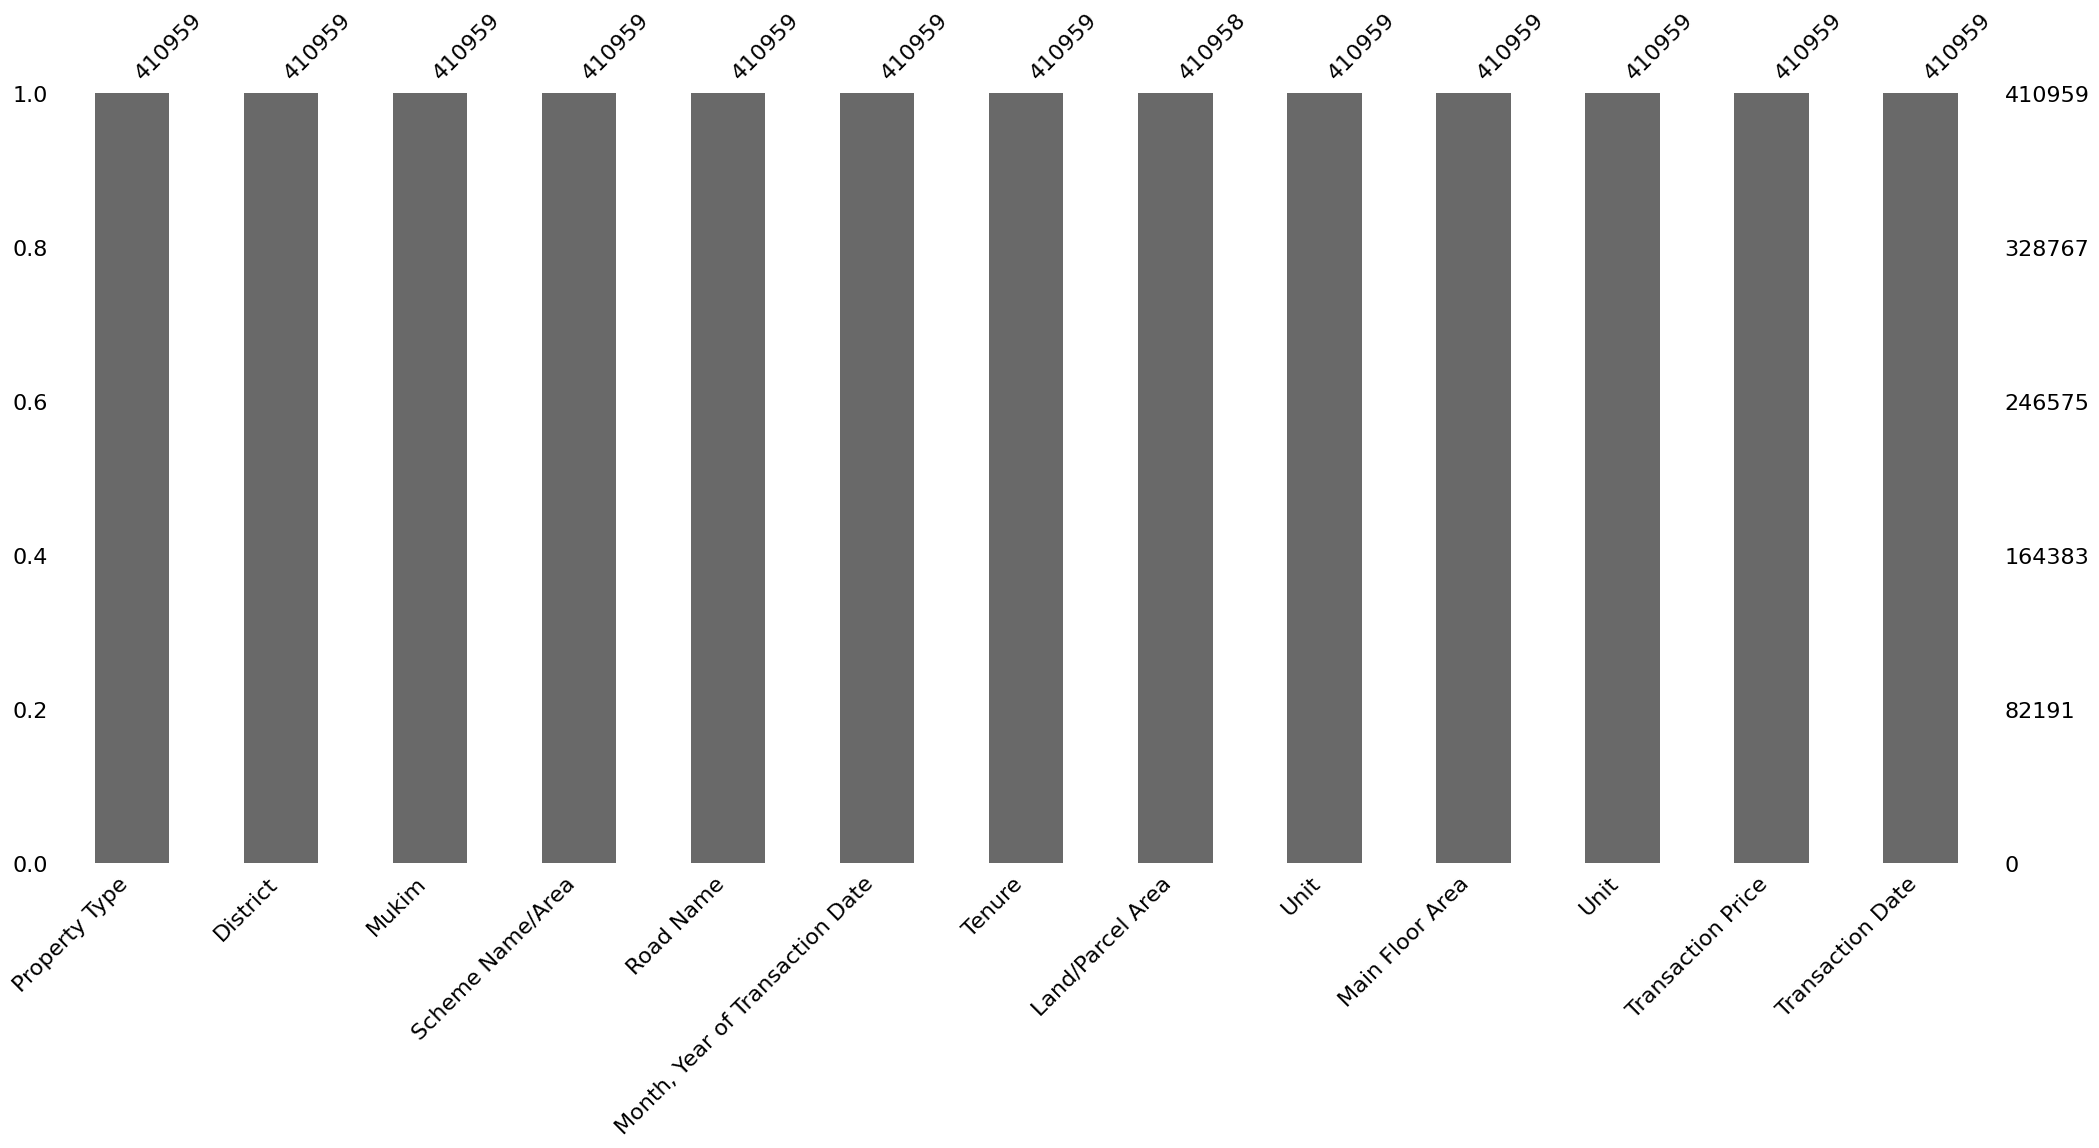

In [64]:
msno.bar(df)

<Axes: >

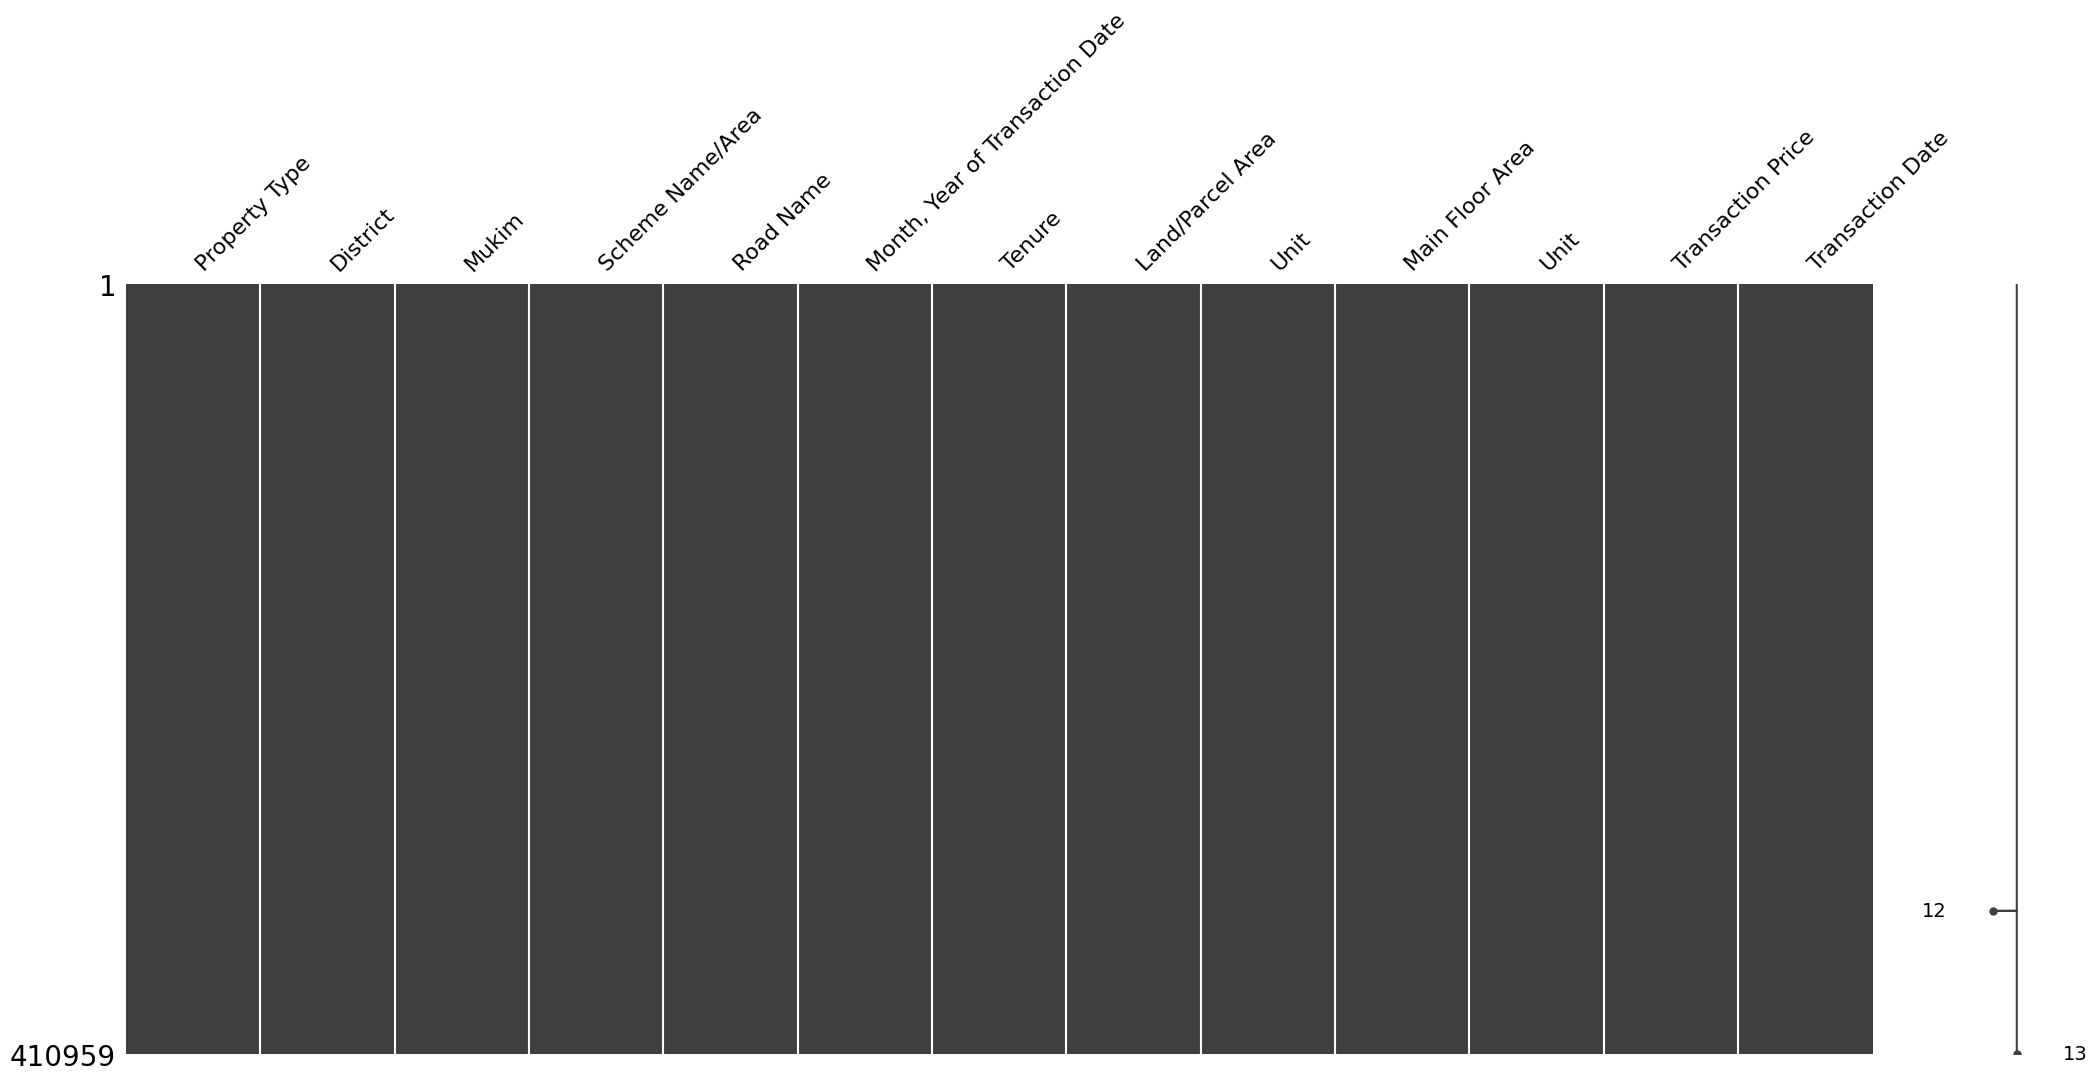

In [65]:
msno.matrix(df) 

**Malaysia Property Analysis**

In [66]:
price = df['Transaction Price'].dropna()

mean_price = price.mean()
median_price = price.median()
mode_price = price.mode()

print("Mean Transaction Price:", mean_price)
print("Median Transaction Price:", median_price)
print("Mode Transaction Price:", mode_price.to_list())


Mean Transaction Price: 499287.7634995218
Median Transaction Price: 370000.0
Mode Transaction Price: [250000.0]


In [67]:
tenure_stats = df.groupby('Tenure')['Transaction Price'].agg(['mean', 'median'])

tenure_mode = df.groupby('Tenure')['Transaction Price'].apply(lambda x: x.mode().tolist())

tenure_stats['mode'] = tenure_mode

print(tenure_stats)

                    mean    median        mode
Tenure                                        
Freehold   547957.410924  400000.0  [300000.0]
Leasehold  403244.325787  315000.0  [250000.0]


In [68]:
property_stats = df.groupby('Property Type')['Transaction Price'].agg(['mean', 'median'])

property_mode = df.groupby('Property Type')['Transaction Price'].apply(lambda x: x.mode().tolist())

property_stats['mode'] = property_mode

print(property_stats)

                                        mean    median        mode
Property Type                                                     
1 - 1 1/2 Storey Semi-Detached  4.091969e+05  380000.0  [350000.0]
1 - 1 1/2 Storey Terraced       3.142851e+05  285000.0  [250000.0]
2 - 2 1/2 Storey Semi-Detached  1.123418e+06  870000.0  [500000.0]
2 - 2 1/2 Storey Terraced       6.126363e+05  539000.0  [500000.0]
Cluster House                   6.395521e+05  537000.0  [250000.0]
Condominium/Apartment           5.423499e+05  385000.0  [300000.0]
Detached                        1.092008e+06  500000.0  [400000.0]
Flat                            2.234734e+05  210000.0  [150000.0]
Low-Cost Flat                   1.436604e+05  145000.0  [150000.0]
Low-Cost House                  2.017787e+05  190000.0  [200000.0]
Town House                      4.476469e+05  360000.0  [150000.0]
